# Better Stress Experiments for `MDSTorusProjector`

This notebook is a bounded experiment harness for stress minimization variants that could replace or inform `sgd_minibatch_njit` inside `MDSTorusProjector.fit_transform(...)`.

Scope:
- reuse the existing graph families from `comparison.ipynb`
- keep runtime bounded and memory usage conservative
- compare candidate optimizers on the same graphs, seeds, and pair budget
- rank candidates by final stress and runtime


In [14]:
import warnings
import pandas as pd
%load_ext autoreload
%autoreload 2

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", message="Unable to import Axes3D")

from modules import stress_experiments as experiments


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports / Setup

The benchmark uses a fixed pair budget per run to keep comparisons bounded. All kernels are warmed up once before timing so the runtime measurements are not dominated by Numba compilation.


In [15]:
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

BENCHMARK_KWARGS = {
    "learning_rate": 1.0,
    "max_iters": 120,
    "batch_pairs": 2048,
    "alpha_init": 1.0,
    "alpha_ema": 0.05,
    "learn_mode": "alpha",
    "geom_lr": 0.01,
    "theta": np.pi / 2,
}
SEEDS = (0, 1, 2)
CHEN_INDICES = None
VARIANT_NAMES = [variant.name for variant in experiments.VARIANTS]
VARIANT_NAMES.remove("full_sweep_sync_sqrtnorm")
VARIANT_NAMES.remove("anchor_unique_online")
VARIANT_NAMES.remove("coverage_unique_sync_sqrtnorm")
print("Variants:", VARIANT_NAMES, "")

print("Warming up Numba kernels...")
experiments.warmup_variants()
print("Warmup complete.")


Variants: ['baseline_random_minibatch', 'sampled_unique_online', 'sampled_unique_sync_batchavg', 'sampled_unique_sync_countnorm', 'sampled_unique_sync_sqrtnorm', 'sampled_unique_sync_hybridnorm', 'stratified_distance_sync_sqrtnorm'] 
Warming up Numba kernels...
Warmup complete.


## Reusable Experimental Kernels

These candidates keep a compatible high-level signature while changing the optimization mechanics:

- `baseline_random_minibatch`: current behavior
- `sampled_unique_online`: unique unordered pairs, online updates
- `sampled_unique_sync_batchavg`: unique unordered pairs, synchronous batch update
- `sampled_unique_sync_countnorm`: synchronous batch update with per-node averaging
- `sampled_unique_sync_sqrtnorm`: synchronous batch update with inverse-sqrt visit normalization
- `sampled_unique_sync_hybridnorm`: early `sqrtnorm`, late `countnorm`
- `stratified_distance_sync_sqrtnorm`: `sqrtnorm` with short/medium/long distance-balanced minibatches
- `coverage_unique_sync_sqrtnorm`: `sqrtnorm` with coverage-constrained node-round minibatches
- `anchor_unique_online`: anchor sweep with a few unique partners per node
- `full_sweep_sync_sqrtnorm`: small-graph full sweep control


In [3]:
variant_catalog = experiments.variant_catalog_df()
display(variant_catalog)


,variant,sampling,order,updates,full_sweep,max_n,description
0,baseline_random_minibatch,random pairs with replacement,fully random,online pairwise,False,NaN,Current baseline: random unordered pairs with replacement and immediate pairwise updates.
1,sampled_unique_online,unique unordered minibatch,random minibatch,online pairwise,False,NaN,Minibatch sampled without replacement from unique unordered pairs; updates applied immediately.
2,sampled_unique_sync_batchavg,unique unordered minibatch,random minibatch,synchronous batch average,False,NaN,Unique unordered minibatch with synchronous node updates from accumulated pair gradients.
3,sampled_unique_sync_countnorm,unique unordered minibatch,random minibatch,synchronous per-node average,False,NaN,Synchronous minibatch update with per-node averaging by visit count.
4,sampled_unique_sync_sqrtnorm,unique unordered minibatch,random minibatch,synchronous inverse-sqrt visit normalization,False,NaN,Synchronous minibatch update with inverse-sqrt visit normalization to keep highly visited nodes stable while preserv...
5,sampled_unique_sync_hybridnorm,unique unordered minibatch,"random minibatch, staged schedule",synchronous sqrtnorm then synchronous countnorm,False,NaN,"Two-stage torus optimizer: early inverse-sqrt normalized synchronous updates, followed by per-node average normaliza..."
6,stratified_distance_sync_sqrtnorm,distance-stratified unique minibatch,random within distance strata,synchronous inverse-sqrt visit normalization,False,NaN,"Inverse-sqrt normalized synchronous updates with minibatches balanced across short, medium, and long target graph di..."
7,coverage_unique_sync_sqrtnorm,coverage-constrained unique minibatch,random node-cover rounds,synchronous inverse-sqrt visit normalization,False,NaN,Inverse-sqrt normalized synchronous updates with minibatches assembled from repeated near-perfect node-covering rounds.
8,anchor_unique_online,anchor-driven unique partners,random anchor sweep,online pairwise,False,NaN,"Anchor-node sweep: random node order, a few unique partners per anchor, immediate pairwise updates."
9,full_sweep_sync_sqrtnorm,all unique unordered pairs,random full sweep,synchronous inverse-sqrt visit normalization,True,120.0,Small-graph control: shuffled full sweep over all unique pairs with synchronous inverse-sqrt normalized updates.


## Evaluation Helpers

The benchmark harness records:
- runtime
- normalized stress under the fitted rectangular torus geometry
- distortion
- `SGS` and neighborhood precision for graphs up to 400 nodes


In [4]:
def top_variants_for_dataset(dataset_name: str, dataset_means: pd.DataFrame, k: int = 3) -> list[str]:
    rows = (
        dataset_means.loc[dataset_means["dataset"] == dataset_name]
        .sort_values(["mean_stress", "mean_runtime_s"])
        .head(k)
    )
    return rows["variant"].tolist()


def display_summary_tables(results_df: pd.DataFrame):
    summary = experiments.summarize_results(results_df)
    recommendation_df = experiments.recommendation_table(results_df)

    display(Markdown("### Overall mean/median performance"))
    display(summary["overall"])

    display(Markdown("### Mean performance by graph family"))
    display(summary["by_group"])

    display(Markdown("### Best mean variant per dataset"))
    display(summary["best_by_dataset"])

    display(Markdown("### Recommendation ranking"))
    display(recommendation_df)

    return summary, recommendation_df


## Benchmark Graph Construction / Loading

The dataset families match `comparison.ipynb`:
- periodic grids
- Chen graphs from `chengraphs/*.json`
- planted partition graphs

The Chen set is intentionally a representative subset here to keep the notebook bounded.


In [5]:
benchmark_specs = experiments.build_representative_benchmarks(
    chen_indices=CHEN_INDICES,
    include_large_grid=True,
    planted_seed=0,
)
benchmark_catalog = experiments.benchmark_catalog_df(benchmark_specs)
display(benchmark_catalog)


,dataset,group,n_nodes,n_edges,nx_size,ny_size,source_layout_available,k,nodes_per_block,p_in,p_out
0,grid_10x10,grid_graphs,100,200,10.0,10.0,NaN,NaN,NaN,NaN,NaN
1,grid_20x20,grid_graphs,400,800,20.0,20.0,NaN,NaN,NaN,NaN,NaN
2,grid_10x30,grid_graphs,300,600,10.0,30.0,NaN,NaN,NaN,NaN,NaN
3,grid_30x30,grid_graphs,900,1800,30.0,30.0,NaN,NaN,NaN,NaN,NaN
4,grid_40x40,grid_graphs,1600,3200,40.0,40.0,NaN,NaN,NaN,NaN,NaN
5,grid_20x60,grid_graphs,1200,2400,20.0,60.0,NaN,NaN,NaN,NaN,NaN
6,grid_15x75,grid_graphs,1125,2250,15.0,75.0,NaN,NaN,NaN,NaN,NaN
7,grid_25x35,grid_graphs,875,1750,25.0,35.0,NaN,NaN,NaN,NaN,NaN
8,chen_1,chengraphs,71,709,NaN,NaN,False,NaN,NaN,NaN,NaN
9,chen_2,chengraphs,69,728,NaN,NaN,False,NaN,NaN,NaN,NaN


## Benchmark Execution

Every variant is run on the same graph, the same seeds, and the same nominal pair budget (`max_iters * batch_pairs`). The full-sweep control converts that budget into a bounded number of full passes and skips larger graphs explicitly.


In [6]:
results_df, embedding_store = experiments.benchmark_variants(
    benchmark_specs,
    variant_names=VARIANT_NAMES,
    seeds=SEEDS,
    compute_extra_metrics=True,
    max_extra_metric_n=400,
    store_embeddings=True,
    **BENCHMARK_KWARGS,
)

display(results_df.head(20))
print("Completed runs:", int((results_df["status"] == "ok").sum()))
print("Skipped runs:", int((results_df["status"] == "skipped").sum()))


,dataset,group,variant,seed,status,skip_reason,n_nodes,n_edges,runtime_s,pair_evals,...,order,updates,description,nx_size,ny_size,source_layout_available,k,nodes_per_block,p_in,p_out
0,grid_10x10,grid_graphs,baseline_random_minibatch,0,ok,,100,200,0.0286,245760,...,fully random,online pairwise,Current baseline: random unordered pairs with replacement and immediate pairwise updates.,10.0,10.0,NaN,NaN,NaN,NaN,NaN
1,grid_10x10,grid_graphs,sampled_unique_online,0,ok,,100,200,0.0372,245760,...,random minibatch,online pairwise,Minibatch sampled without replacement from unique unordered pairs; updates applied immediately.,10.0,10.0,NaN,NaN,NaN,NaN,NaN
2,grid_10x10,grid_graphs,sampled_unique_sync_batchavg,0,ok,,100,200,0.0343,245760,...,random minibatch,synchronous batch average,Unique unordered minibatch with synchronous node updates from accumulated pair gradients.,10.0,10.0,NaN,NaN,NaN,NaN,NaN
3,grid_10x10,grid_graphs,sampled_unique_sync_countnorm,0,ok,,100,200,0.0506,245760,...,random minibatch,synchronous per-node average,Synchronous minibatch update with per-node averaging by visit count.,10.0,10.0,NaN,NaN,NaN,NaN,NaN
4,grid_10x10,grid_graphs,sampled_unique_sync_sqrtnorm,0,ok,,100,200,0.0337,245760,...,random minibatch,synchronous inverse-sqrt visit normalization,Synchronous minibatch update with inverse-sqrt visit normalization to keep highly visited nodes stable while preserv...,10.0,10.0,NaN,NaN,NaN,NaN,NaN
5,grid_10x10,grid_graphs,sampled_unique_sync_hybridnorm,0,ok,,100,200,0.0364,245760,...,"random minibatch, staged schedule",synchronous sqrtnorm then synchronous countnorm,"Two-stage torus optimizer: early inverse-sqrt normalized synchronous updates, followed by per-node average normaliza...",10.0,10.0,NaN,NaN,NaN,NaN,NaN
6,grid_10x10,grid_graphs,stratified_distance_sync_sqrtnorm,0,ok,,100,200,0.0561,245760,...,random within distance strata,synchronous inverse-sqrt visit normalization,"Inverse-sqrt normalized synchronous updates with minibatches balanced across short, medium, and long target graph di...",10.0,10.0,NaN,NaN,NaN,NaN,NaN
7,grid_10x10,grid_graphs,baseline_random_minibatch,1,ok,,100,200,0.0337,245760,...,fully random,online pairwise,Current baseline: random unordered pairs with replacement and immediate pairwise updates.,10.0,10.0,NaN,NaN,NaN,NaN,NaN
8,grid_10x10,grid_graphs,sampled_unique_online,1,ok,,100,200,0.0369,245760,...,random minibatch,online pairwise,Minibatch sampled without replacement from unique unordered pairs; updates applied immediately.,10.0,10.0,NaN,NaN,NaN,NaN,NaN
9,grid_10x10,grid_graphs,sampled_unique_sync_batchavg,1,ok,,100,200,0.0329,245760,...,random minibatch,synchronous batch average,Unique unordered minibatch with synchronous node updates from accumulated pair gradients.,10.0,10.0,NaN,NaN,NaN,NaN,NaN


Completed runs: 756
Skipped runs: 0


In [7]:
ok_results = results_df.loc[results_df["status"] == "ok"].copy()
summary, recommendation_df = display_summary_tables(results_df)
dataset_means = summary["dataset_means"]


### Overall mean/median performance

,variant,runs,mean_stress,median_stress,mean_runtime_s,median_runtime_s,mean_stress_delta,mean_runtime_ratio
0,stratified_distance_sync_sqrtnorm,108,0.2706,0.2823,0.0581,0.0471,-0.1170,1.6435
1,sampled_unique_sync_sqrtnorm,108,0.2725,0.2770,0.0399,0.0323,-0.1151,1.1239
2,sampled_unique_sync_countnorm,108,0.3322,0.3009,0.0410,0.0322,-0.0554,1.1418
3,sampled_unique_sync_hybridnorm,108,0.3322,0.2986,0.0418,0.0337,-0.0553,1.1666
4,sampled_unique_online,108,0.3841,0.3580,0.0410,0.0331,-0.0035,1.1496
5,sampled_unique_sync_batchavg,108,0.3849,0.4050,0.0396,0.0332,-0.0027,1.1198
6,baseline_random_minibatch,108,0.3876,0.3715,0.0358,0.0294,0.0000,1.0000


### Mean performance by graph family

,group,variant,runs,mean_stress,median_stress,mean_runtime_s,mean_stress_delta
0,chengraphs,sampled_unique_sync_sqrtnorm,60,0.2776,0.2724,0.0335,-0.0506
1,chengraphs,sampled_unique_sync_hybridnorm,60,0.2779,0.2724,0.0339,-0.0504
2,chengraphs,stratified_distance_sync_sqrtnorm,60,0.2797,0.2783,0.0482,-0.0485
3,chengraphs,sampled_unique_sync_countnorm,60,0.2853,0.2910,0.0342,-0.0430
4,chengraphs,sampled_unique_online,60,0.3219,0.3267,0.0348,-0.0063
5,chengraphs,baseline_random_minibatch,60,0.3283,0.3287,0.0303,0.0000
6,chengraphs,sampled_unique_sync_batchavg,60,0.4054,0.4052,0.0347,0.0772
7,grid_graphs,stratified_distance_sync_sqrtnorm,24,0.1575,0.1503,0.0866,-0.3520
8,grid_graphs,sampled_unique_sync_sqrtnorm,24,0.1668,0.1581,0.0619,-0.3427
9,grid_graphs,sampled_unique_sync_batchavg,24,0.3051,0.3318,0.0585,-0.2044


### Best mean variant per dataset

,dataset,group,variant,mean_stress,mean_runtime_s,mean_stress_delta
0,chen_1,chengraphs,sampled_unique_sync_hybridnorm,0.2646,0.0334,-0.0507
1,chen_10,chengraphs,stratified_distance_sync_sqrtnorm,0.2558,0.0496,-0.0351
2,chen_11,chengraphs,sampled_unique_sync_sqrtnorm,0.3008,0.0359,-0.0583
3,chen_12,chengraphs,sampled_unique_sync_sqrtnorm,0.2939,0.0302,-0.0649
4,chen_13,chengraphs,stratified_distance_sync_sqrtnorm,0.2935,0.0447,-0.0573
5,chen_14,chengraphs,sampled_unique_sync_sqrtnorm,0.2969,0.0360,-0.0660
6,chen_15,chengraphs,sampled_unique_sync_sqrtnorm,0.3130,0.0338,-0.0586
7,chen_16,chengraphs,sampled_unique_sync_hybridnorm,0.2983,0.0303,-0.0739
8,chen_17,chengraphs,sampled_unique_sync_sqrtnorm,0.2848,0.0287,-0.0622
9,chen_18,chengraphs,sampled_unique_sync_sqrtnorm,0.2972,0.0284,-0.0648


### Recommendation ranking

,variant,runs,mean_stress,median_stress,mean_runtime_s,median_runtime_s,mean_stress_delta,mean_runtime_ratio,dataset_wins,stress_rank,runtime_rank,overall_score
0,sampled_unique_sync_sqrtnorm,108,0.2725,0.2770,0.0399,0.0323,-0.1151,1.1239,15,2.0,3.0,3.05
1,stratified_distance_sync_sqrtnorm,108,0.2706,0.2823,0.0581,0.0471,-0.1170,1.6435,11,1.0,7.0,3.45
2,sampled_unique_sync_countnorm,108,0.3322,0.3009,0.0410,0.0322,-0.0554,1.1418,8,3.0,5.0,4.75
3,sampled_unique_sync_hybridnorm,108,0.3322,0.2986,0.0418,0.0337,-0.0553,1.1666,2,4.0,6.0,6.10
4,sampled_unique_online,108,0.3841,0.3580,0.0410,0.0331,-0.0035,1.1496,0,5.0,4.0,6.40
5,sampled_unique_sync_batchavg,108,0.3849,0.4050,0.0396,0.0332,-0.0027,1.1198,0,6.0,2.0,6.70
6,baseline_random_minibatch,108,0.3876,0.3715,0.0358,0.0294,0.0000,1.0000,0,7.0,1.0,7.35


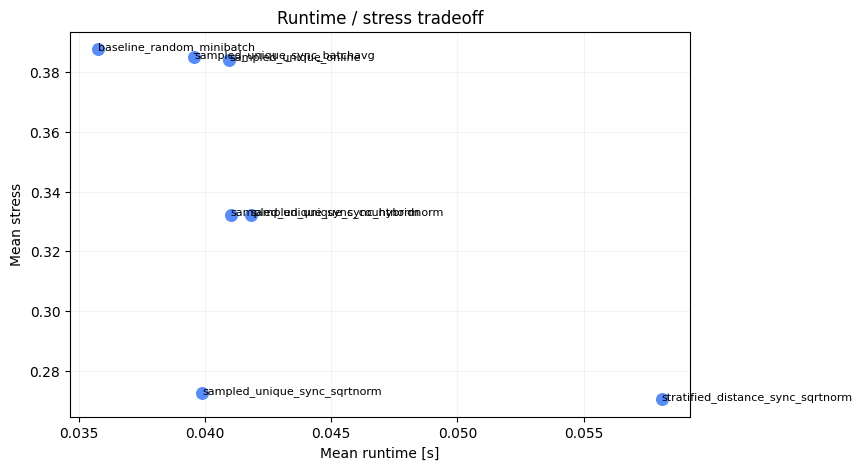

In [8]:
overall_plot = summary["overall"].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(overall_plot["mean_runtime_s"], overall_plot["mean_stress"], s=70)
for _, row in overall_plot.iterrows():
    ax.text(row["mean_runtime_s"], row["mean_stress"], row["variant"], fontsize=8)
ax.set_xlabel("Mean runtime [s]")
ax.set_ylabel("Mean stress")
ax.set_title("Runtime / stress tradeoff")
ax.grid(alpha=0.2)
plt.show()


## Controlled Test 1: Same Optimizers Under Euclidean Stress

This control keeps the optimizer mechanics fixed but swaps the torus objective for plain Euclidean pairwise stress. If the same variant still wins, the effect is mostly optimizer-side rather than torus-specific.


In [12]:
control_specs = [
    spec for spec in benchmark_specs
    if spec.name in {"grid_20x20", "planted_k4_n40", "planted_k4_n80"} or spec.name.startswith("chen_")
]
# control_variant_names = [
#     "baseline_random_minibatch",
#     "sampled_unique_online",
#     "sampled_unique_sync_countnorm",
#     "sampled_unique_sync_sqrtnorm",
# ]
control_variant_names = VARIANT_NAMES

objective_control_df = experiments.benchmark_objective_controls(
    control_specs,
    variant_names=control_variant_names,
    seeds=SEEDS,
    learning_rate=BENCHMARK_KWARGS["learning_rate"],
    max_iters=BENCHMARK_KWARGS["max_iters"],
    batch_pairs=BENCHMARK_KWARGS["batch_pairs"],
    alpha_init=BENCHMARK_KWARGS["alpha_init"],
    alpha_ema=BENCHMARK_KWARGS["alpha_ema"],
    theta=BENCHMARK_KWARGS["theta"],
)
objective_summary = experiments.summarize_objective_controls(objective_control_df)

display(Markdown("### Overall by objective"))
display(objective_summary["overall"])

display(Markdown("### By graph family and objective"))
display(objective_summary["by_group"])


### Overall by objective

,objective,variant,runs,mean_stress,median_stress,mean_runtime_s,mean_stress_delta
0,euclidean,sampled_unique_sync_countnorm,69,0.4284,0.4324,0.0347,-104849.2999
1,euclidean,sampled_unique_sync_hybridnorm,69,0.4346,0.4329,0.0353,-104849.2936
2,euclidean,sampled_unique_sync_sqrtnorm,69,0.4348,0.4313,0.0357,-104849.2934
3,euclidean,stratified_distance_sync_sqrtnorm,69,0.4357,0.4341,0.0480,-104849.2925
4,euclidean,sampled_unique_sync_batchavg,69,0.4763,0.4744,0.0349,-104849.2519
5,euclidean,sampled_unique_online,69,78176.0679,10.8153,0.0349,-26673.6603
6,euclidean,baseline_random_minibatch,69,104849.7282,23.0383,1.0098,0.0000
7,torus,sampled_unique_sync_sqrtnorm,69,0.2747,0.2765,0.0330,-0.0689
8,torus,stratified_distance_sync_sqrtnorm,69,0.2780,0.2852,0.0461,-0.0655
9,torus,sampled_unique_sync_hybridnorm,69,0.2890,0.2880,0.0331,-0.0546


### By graph family and objective

,objective,group,variant,runs,mean_stress,mean_runtime_s,mean_stress_delta
0,euclidean,chengraphs,sampled_unique_sync_countnorm,60,0.4266,0.0340,-1.2058e+05
1,euclidean,chengraphs,sampled_unique_sync_sqrtnorm,60,0.4268,0.0342,-1.2058e+05
2,euclidean,chengraphs,stratified_distance_sync_sqrtnorm,60,0.4275,0.0473,-1.2058e+05
3,euclidean,chengraphs,sampled_unique_sync_hybridnorm,60,0.4289,0.0345,-1.2058e+05
4,euclidean,chengraphs,sampled_unique_sync_batchavg,60,0.4728,0.0340,-1.2058e+05
5,euclidean,chengraphs,sampled_unique_online,60,89902.4128,0.0343,-3.0675e+04
6,euclidean,chengraphs,baseline_random_minibatch,60,120577.1258,0.9990,0.0000e+00
7,euclidean,grid_graphs,sampled_unique_sync_countnorm,3,0.4267,0.0517,-1.5263e-02
8,euclidean,grid_graphs,baseline_random_minibatch,3,0.4420,1.2298,0.0000e+00
9,euclidean,grid_graphs,sampled_unique_online,3,0.4795,0.0456,3.7488e-02


## Controlled Test 2: Torus Visitation and Movement Diagnostics

This diagnostic keeps the torus objective fixed and logs per-epoch statistics for visit imbalance, pair-gradient magnitudes, and resulting node movement magnitudes.


In [19]:
diagnostic_datasets = ["grid_20x20", "chen_10", "planted_k4_n80"]
# diagnostic_variants = [
#     "baseline_random_minibatch",
#     "sampled_unique_sync_countnorm",
#     "sampled_unique_sync_sqrtnorm",
# ]
diagnostic_variants = VARIANT_NAMES
diagnostic_variants.remove("sampled_unique_online")

diagnostic_rows = []
for dataset_name in diagnostic_datasets:
    spec = next(spec for spec in benchmark_specs if spec.name == dataset_name)
    for variant_name in diagnostic_variants:
        diag_df = experiments.diagnose_torus_optimization(
            spec.distances,
            variant_name,
            learning_rate=BENCHMARK_KWARGS["learning_rate"],
            max_iters=BENCHMARK_KWARGS["max_iters"],
            batch_pairs=BENCHMARK_KWARGS["batch_pairs"],
            seed=0,
            alpha_init=BENCHMARK_KWARGS["alpha_init"],
            alpha_ema=BENCHMARK_KWARGS["alpha_ema"],
            theta=BENCHMARK_KWARGS["theta"],
        )
        diag_df["dataset"] = dataset_name
        diagnostic_rows.append(diag_df)

diagnostic_df = pd.concat(diagnostic_rows, ignore_index=True)
diagnostic_summary = (
    diagnostic_df.groupby(["dataset", "variant"], as_index=False)
    .agg(
        mean_visit_cv=("visit_cv", "mean"),
        mean_pair_grad_norm=("mean_pair_grad_norm", "mean"),
        mean_node_move_norm=("mean_node_move_norm", "mean"),
        max_node_move_norm=("max_node_move_norm", "mean"),
    )
    .sort_values(["dataset", "mean_visit_cv", "mean_node_move_norm"])
)
display(diagnostic_summary)


,dataset,variant,mean_visit_cv,mean_pair_grad_norm,mean_node_move_norm,max_node_move_norm
3,chen_10,sampled_unique_sync_hybridnorm,0.0543,3.0823,0.0301,0.0635
5,chen_10,stratified_distance_sync_sqrtnorm,0.0544,3.0882,0.0280,0.0659
1,chen_10,sampled_unique_sync_batchavg,0.0546,4.1171,0.0005,0.0012
2,chen_10,sampled_unique_sync_countnorm,0.0546,3.1226,0.0167,0.0386
4,chen_10,sampled_unique_sync_sqrtnorm,0.0546,3.0830,0.0308,0.0655
0,chen_10,baseline_random_minibatch,0.1296,3.8115,8.9712,12.4824
11,grid_20x20,stratified_distance_sync_sqrtnorm,0.3065,76.9884,0.0626,0.1894
9,grid_20x20,sampled_unique_sync_hybridnorm,0.3077,132.6657,0.2021,0.7403
7,grid_20x20,sampled_unique_sync_batchavg,0.3079,150.1159,0.0076,0.0254
10,grid_20x20,sampled_unique_sync_sqrtnorm,0.3079,76.1234,0.0603,0.1805


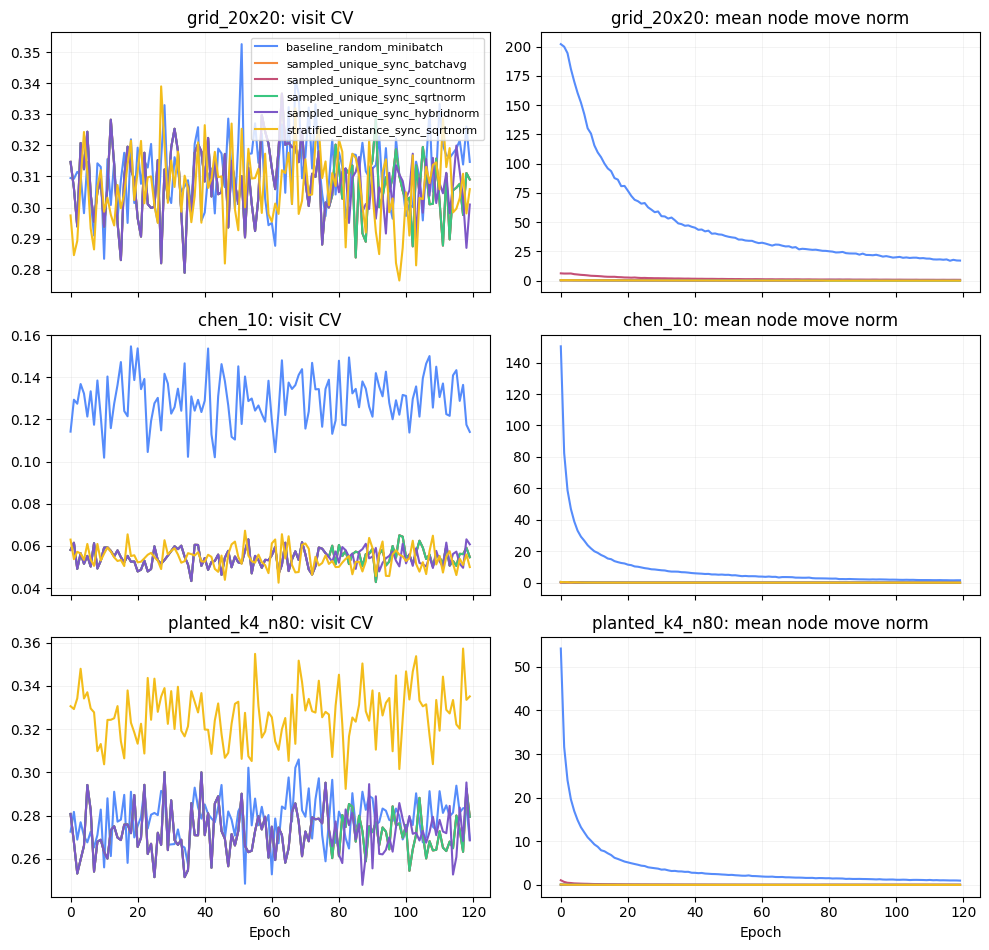

In [20]:
fig, axes = plt.subplots(len(diagnostic_datasets), 2, figsize=(10, 3.2 * len(diagnostic_datasets)), sharex=True)
if len(diagnostic_datasets) == 1:
    axes = np.array([axes])

for row_idx, dataset_name in enumerate(diagnostic_datasets):
    subset = diagnostic_df.loc[diagnostic_df["dataset"] == dataset_name]
    for variant_name in diagnostic_variants:
        variant_subset = subset.loc[subset["variant"] == variant_name]
        axes[row_idx, 0].plot(variant_subset["epoch"], variant_subset["visit_cv"], label=variant_name)
        axes[row_idx, 1].plot(variant_subset["epoch"], variant_subset["mean_node_move_norm"], label=variant_name)
    axes[row_idx, 0].set_title(f"{dataset_name}: visit CV")
    axes[row_idx, 1].set_title(f"{dataset_name}: mean node move norm")
    axes[row_idx, 0].grid(alpha=0.2)
    axes[row_idx, 1].grid(alpha=0.2)

axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()


## Broader Scenario Suite

This repeats the control experiments on a wider variety of graph families:

- torus-native periodic graphs
- Euclidean-native planar and geometric graphs
- random / structured generator graphs
- Chen graphs
- planted partition graphs

For the torus objective, the original learning-rate schedule is kept. For the Euclidean control, a more conservative schedule is used so the comparison reflects optimizer behavior rather than numerical blow-up.


In [21]:
diverse_specs = experiments.build_diverse_control_benchmarks(seed=0)
# diverse_variant_names = [
#     "baseline_random_minibatch",
#     "sampled_unique_online",
#     "sampled_unique_sync_countnorm",
#     "sampled_unique_sync_sqrtnorm",
#     "sampled_unique_sync_hybridnorm",
#     "stratified_distance_sync_sqrtnorm",
#     "coverage_unique_sync_sqrtnorm",
# ]
diverse_variant_names = VARIANT_NAMES
diverse_seeds = (0, 1)
display(experiments.benchmark_catalog_df(diverse_specs))


,dataset,group,n_nodes,n_edges,nx_size,ny_size,diagonal,generator,n,radius,k,p,m,dimension,branching,height,source_layout_available,nodes_per_block,p_in,p_out
0,torus_grid_10x10,torus_native,100,200,10.0,10.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,torus_grid_12x24,torus_native,288,576,12.0,24.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,torus_diag_10x10,torus_native,100,400,10.0,10.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,torus_diag_16x16,torus_native,256,1024,16.0,16.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,planar_grid_10x10,euclidean_native,100,180,10.0,10.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,planar_diag_grid_12x12,euclidean_native,144,506,12.0,12.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,random_geometric_140,euclidean_native,140,935,NaN,NaN,NaN,random_geometric_graph,140.0,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,knn_gaussian_clusters_140,euclidean_native,140,716,NaN,NaN,NaN,knn_gaussian_clusters,140.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,erdos_renyi_120,random_structured,120,456,NaN,NaN,NaN,erdos_renyi,120.0,NaN,NaN,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,watts_strogatz_120,random_structured,120,360,NaN,NaN,NaN,watts_strogatz,120.0,NaN,6.0,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
diverse_torus_df = experiments.benchmark_objective_controls(
    diverse_specs,
    variant_names=diverse_variant_names,
    objectives=("torus",),
    seeds=diverse_seeds,
    learning_rate=1.0,
    max_iters=120,
    batch_pairs=2048,
    alpha_init=1.0,
    alpha_ema=0.05,
    theta=np.pi / 2,
)
diverse_torus_df = diverse_torus_df.loc[diverse_torus_df["objective"] == "torus"].copy()
diverse_torus_summary = experiments.summarize_objective_controls(diverse_torus_df)

display(Markdown("### Broader torus summary"))
display(diverse_torus_summary["overall"])
display(diverse_torus_summary["by_group"])


### Broader torus summary

,objective,variant,runs,mean_stress,median_stress,mean_runtime_s,mean_stress_delta
0,torus,stratified_distance_sync_sqrtnorm,72,0.2640,0.2616,0.0645,-0.1286
1,torus,sampled_unique_sync_sqrtnorm,72,0.2671,0.2620,0.0435,-0.1256
2,torus,sampled_unique_sync_countnorm,72,0.2844,0.2934,0.0440,-0.1082
3,torus,sampled_unique_sync_hybridnorm,72,0.2868,0.2881,0.0450,-0.1058
4,torus,sampled_unique_sync_batchavg,72,0.3879,0.4037,0.0449,-0.0047
5,torus,baseline_random_minibatch,72,0.3926,0.3722,0.0410,0.0000


,objective,group,variant,runs,mean_stress,mean_runtime_s,mean_stress_delta
0,torus,chengraphs,sampled_unique_sync_sqrtnorm,40,0.2774,0.0408,-0.0512
1,torus,chengraphs,sampled_unique_sync_hybridnorm,40,0.2777,0.0430,-0.0510
2,torus,chengraphs,stratified_distance_sync_sqrtnorm,40,0.2799,0.0616,-0.0488
3,torus,chengraphs,sampled_unique_sync_countnorm,40,0.2843,0.0422,-0.0443
4,torus,chengraphs,baseline_random_minibatch,40,0.3287,0.0396,0.0000
5,torus,chengraphs,sampled_unique_sync_batchavg,40,0.4022,0.0433,0.0735
6,torus,euclidean_native,stratified_distance_sync_sqrtnorm,8,0.2186,0.0658,-0.3226
7,torus,euclidean_native,sampled_unique_sync_sqrtnorm,8,0.2222,0.0457,-0.3190
8,torus,euclidean_native,sampled_unique_sync_countnorm,8,0.3101,0.0435,-0.2311
9,torus,euclidean_native,sampled_unique_sync_batchavg,8,0.3102,0.0429,-0.2311


In [23]:
diverse_euclidean_df = experiments.benchmark_objective_controls(
    diverse_specs,
    variant_names=diverse_variant_names,
    objectives=("euclidean",),
    seeds=diverse_seeds,
    learning_rate=5.0,
    max_iters=120,
    batch_pairs=2048,
    alpha_init=1.0,
    alpha_ema=0.05,
    theta=np.pi / 2,
)
diverse_euclidean_df = diverse_euclidean_df.loc[diverse_euclidean_df["objective"] == "euclidean"].copy()
diverse_euclidean_summary = experiments.summarize_objective_controls(diverse_euclidean_df)

display(Markdown("### Broader Euclidean summary"))
display(diverse_euclidean_summary["overall"])
display(diverse_euclidean_summary["by_group"])


### Broader Euclidean summary

,objective,variant,runs,mean_stress,median_stress,mean_runtime_s,mean_stress_delta
0,euclidean,baseline_random_minibatch,72,0.3150,0.3413,1.7252,0.0000
1,euclidean,sampled_unique_sync_countnorm,72,0.4150,0.4366,0.0518,0.1001
2,euclidean,sampled_unique_sync_hybridnorm,72,0.4218,0.4286,0.0528,0.1068
3,euclidean,sampled_unique_sync_sqrtnorm,72,0.4271,0.4282,0.0521,0.1121
4,euclidean,stratified_distance_sync_sqrtnorm,72,0.4305,0.4283,0.0732,0.1155
5,euclidean,sampled_unique_sync_batchavg,72,0.4859,0.4761,0.0517,0.1710


,objective,group,variant,runs,mean_stress,mean_runtime_s,mean_stress_delta
0,euclidean,chengraphs,baseline_random_minibatch,40,0.3489,1.7821,0.0000
1,euclidean,chengraphs,stratified_distance_sync_sqrtnorm,40,0.4173,0.0731,0.0684
2,euclidean,chengraphs,sampled_unique_sync_sqrtnorm,40,0.4177,0.0526,0.0688
3,euclidean,chengraphs,sampled_unique_sync_hybridnorm,40,0.4198,0.0531,0.0709
4,euclidean,chengraphs,sampled_unique_sync_countnorm,40,0.4331,0.0524,0.0842
5,euclidean,chengraphs,sampled_unique_sync_batchavg,40,0.4723,0.0530,0.1234
6,euclidean,euclidean_native,baseline_random_minibatch,8,0.0874,1.5861,0.0000
7,euclidean,euclidean_native,sampled_unique_sync_countnorm,8,0.2816,0.0509,0.1942
8,euclidean,euclidean_native,sampled_unique_sync_hybridnorm,8,0.3465,0.0502,0.2591
9,euclidean,euclidean_native,sampled_unique_sync_sqrtnorm,8,0.3699,0.0499,0.2825


## Representative Embeddings

The plots below visualize the top variants for one representative graph from each family. This is not part of the ranking logic; it is only a qualitative check that the lower-stress candidates still produce coherent toroidal layouts.


grid_10x10 -> ['stratified_distance_sync_sqrtnorm', 'sampled_unique_sync_sqrtnorm', 'sampled_unique_sync_hybridnorm']


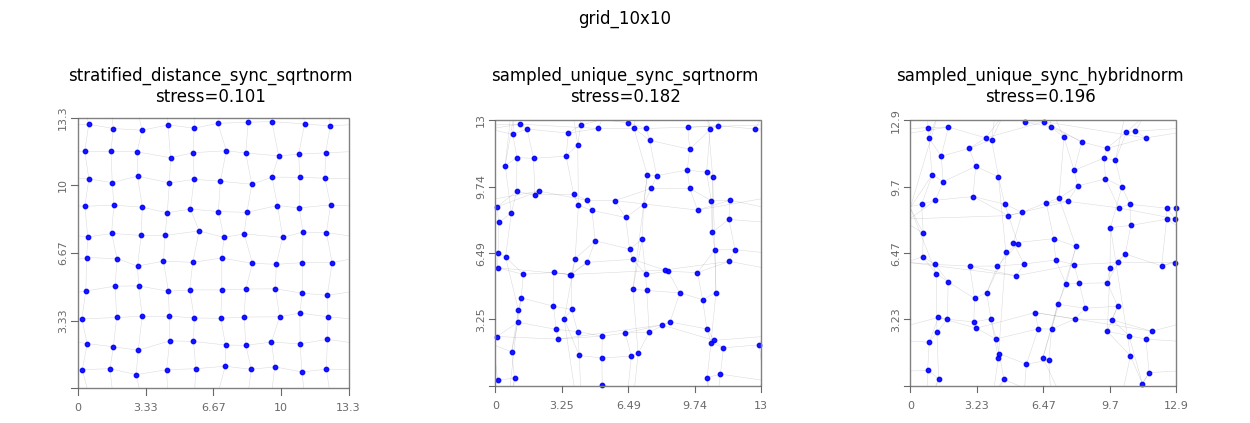

grid_20x20 -> ['sampled_unique_sync_sqrtnorm', 'stratified_distance_sync_sqrtnorm', 'sampled_unique_sync_batchavg']


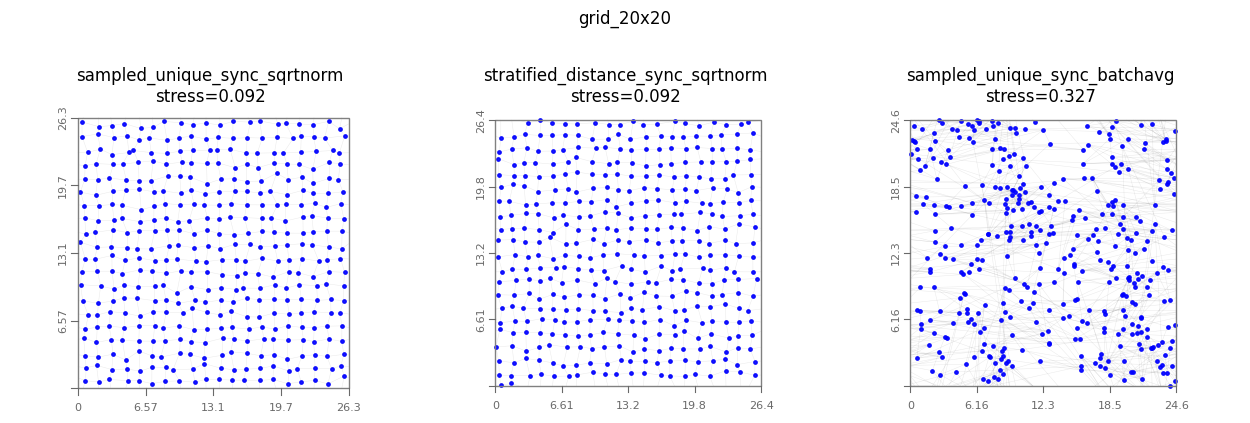

grid_10x30 -> ['stratified_distance_sync_sqrtnorm', 'sampled_unique_sync_sqrtnorm', 'sampled_unique_sync_batchavg']


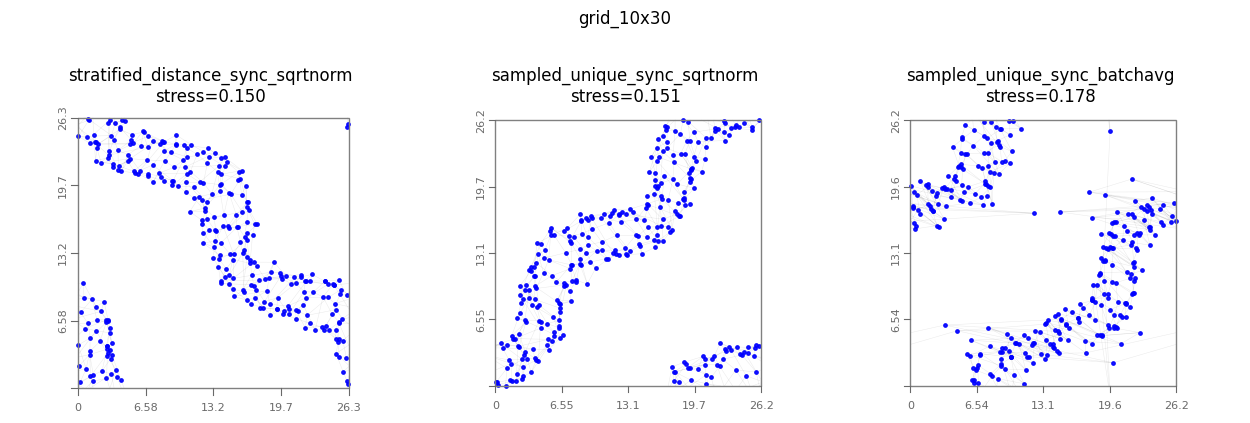

chen_1 -> ['sampled_unique_sync_hybridnorm', 'sampled_unique_sync_sqrtnorm', 'stratified_distance_sync_sqrtnorm']


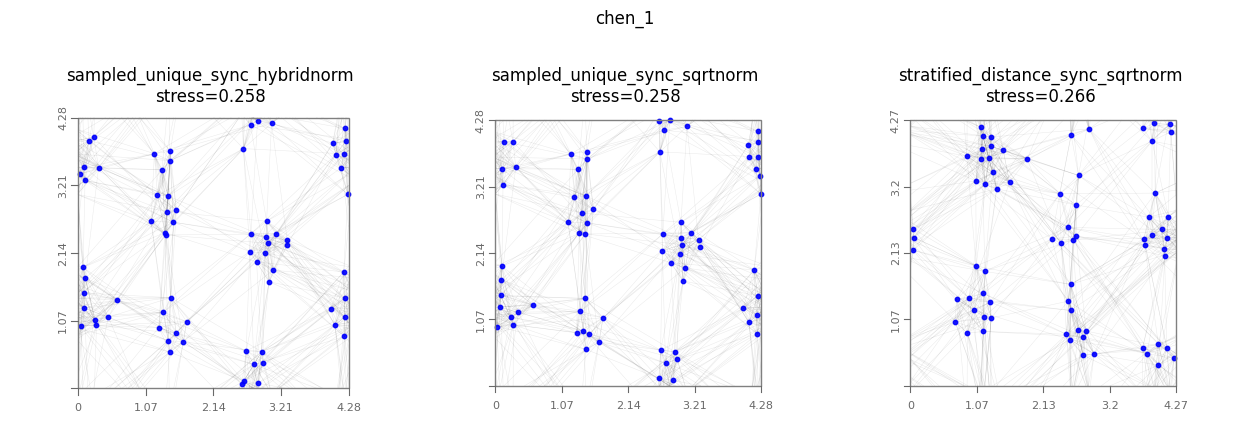

chen_10 -> ['stratified_distance_sync_sqrtnorm', 'sampled_unique_sync_sqrtnorm', 'sampled_unique_sync_hybridnorm']


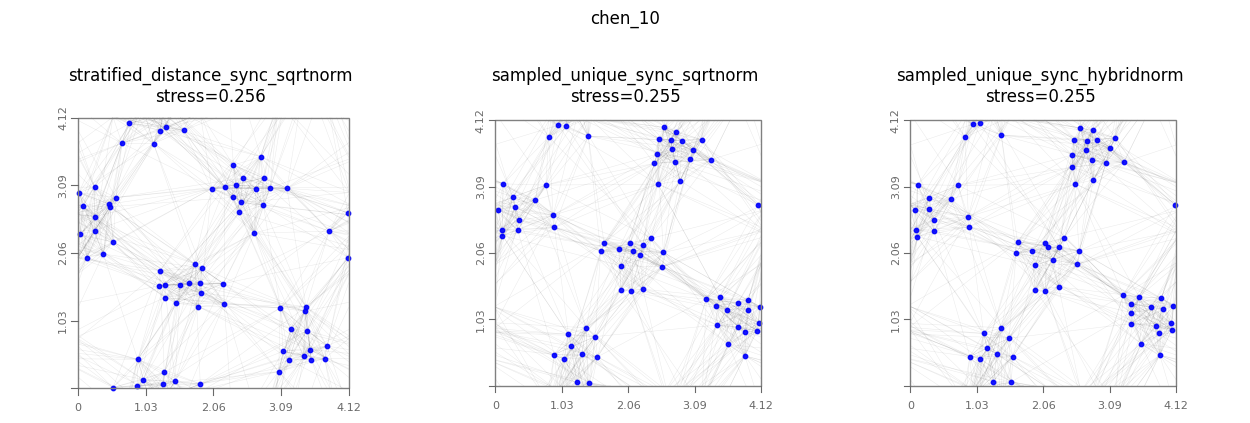

chen_20 -> ['sampled_unique_sync_sqrtnorm', 'sampled_unique_sync_hybridnorm', 'stratified_distance_sync_sqrtnorm']


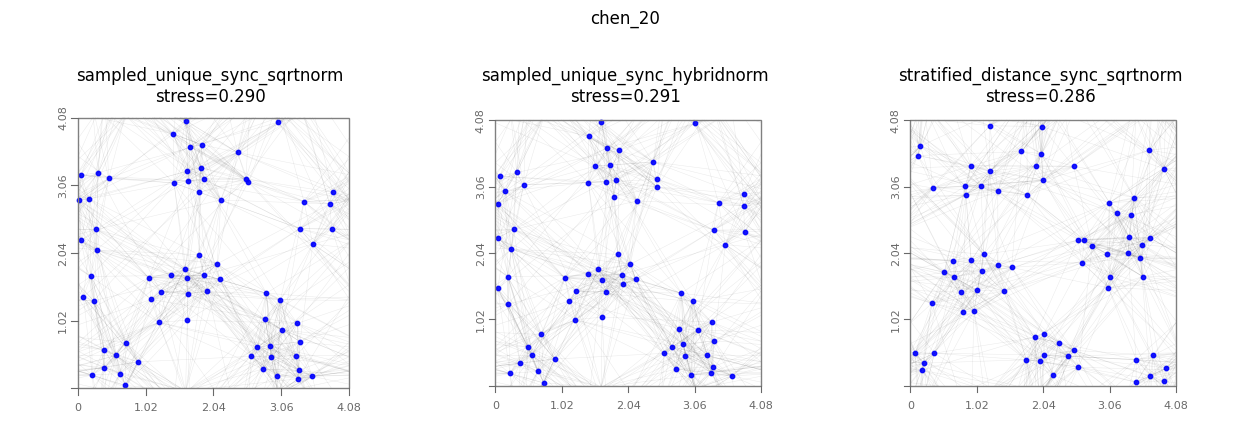

planted_k4_n40 -> ['sampled_unique_sync_countnorm', 'sampled_unique_sync_hybridnorm', 'sampled_unique_sync_sqrtnorm']


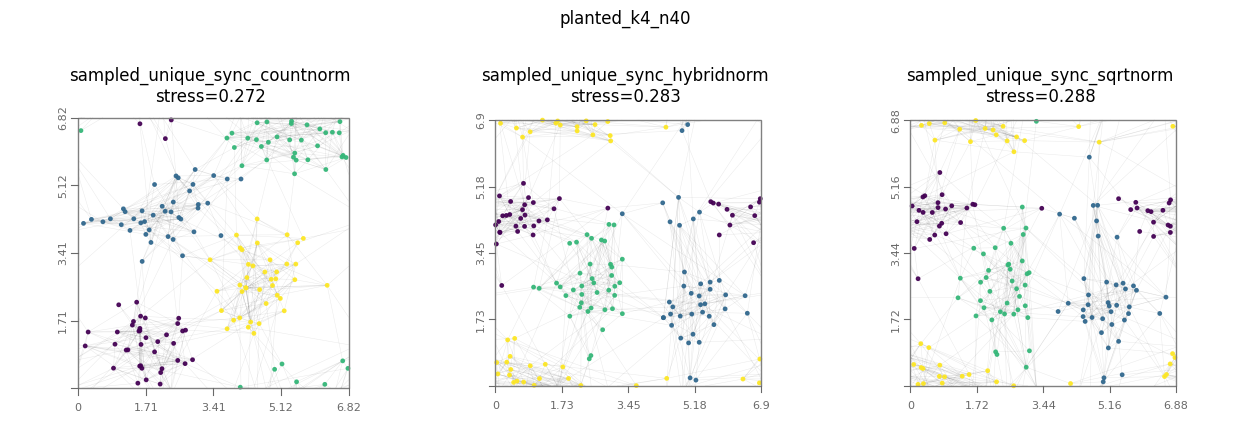

planted_k4_n80 -> ['sampled_unique_sync_countnorm', 'sampled_unique_sync_hybridnorm', 'stratified_distance_sync_sqrtnorm']


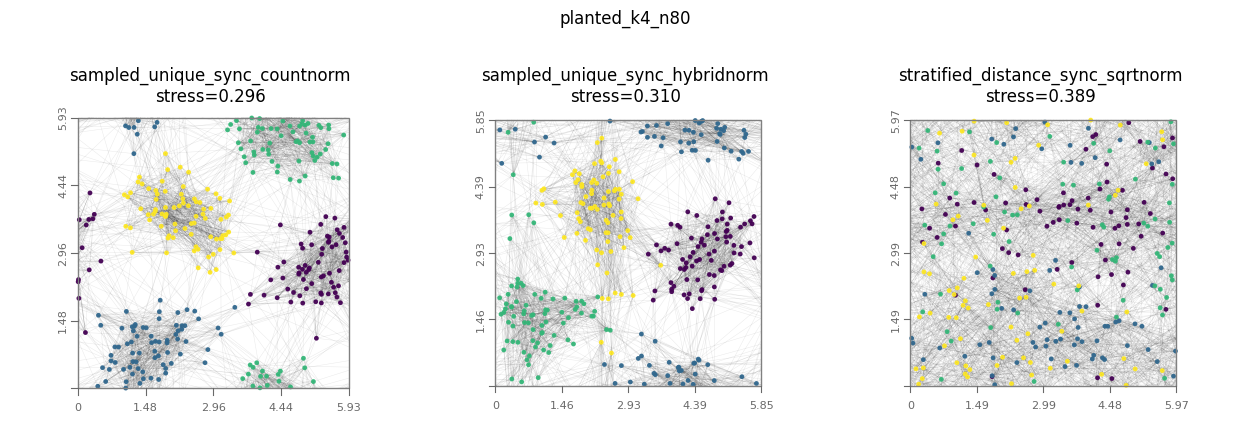

In [24]:
representative_datasets = [
    "grid_10x10",
    "grid_20x20",
    "grid_10x30",
    "chen_1",
    "chen_10",
    "chen_20",
    "planted_k4_n40",
    "planted_k4_n80",
]

for dataset_name in representative_datasets:
    spec = next(spec for spec in benchmark_specs if spec.name == dataset_name)
    chosen_variants = top_variants_for_dataset(dataset_name, dataset_means, k=3)
    print(dataset_name, "->", chosen_variants)
    experiments.plot_representative_embeddings(
        spec,
        embedding_store,
        chosen_variants,
        seed=0,
    )
    plt.show()
